In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie

plt.rcParams['axes.xmargin'] = 0

In [2]:
filename = 'data/agnspec.txt'

# (Optional) Set the source coordinates and redshift
dec, ra = -25.12345, 13.12345
redshift = 0.0622

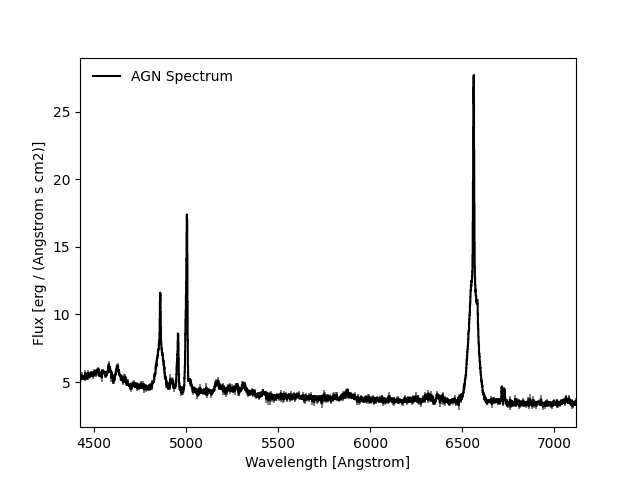

In [3]:
spec = Spectrum.from_txt(filename=filename,
                         ra=ra,
                         dec=dec,
                         z=redshift,
                         wave_unit=u.AA,
                         unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
                         name='AGN Spectrum')

# # (Example) Mask a region
# wmask = (spec.wave <= 5800) | (spec.wave >= 5980)
# spec.crop(wmask=wmask)

# # (Example) Crop a portion of the spectrum
# wbounds = (4800., 7500.) # Å
# spec.crop(wbounds=wbounds)

# Apply Galactic extinction correction
spec.deredden()

# (Optional) Apply redshift correction to rest frame
spec.zcorrect()

spec.plot_spectrum() 

In [4]:
# (Optional) Copy locally the CSV file containing the line list, and set up the local line database.
models.setup_local_lines(wmin=np.min(spec.wave), wmax=np.max(spec.wave), overwrite=True)

# # If you want to blindly proceed with the default line list without inspecting it, you can use models.set_wavelength_range()
# # This will just filter the lines to those that fall within the wavelength range of interest.
# models.set_wavelength_range(wmin=np.min(spec.wave), wmax=np.max(spec.wave))

# NOTE: If you decide to work in the observed frame, you should remember to set the line database to the rest frame, i.e. models.set_wavelength_range(wmin=np.min(spec.wave)/(1+redshift), wmax=np.max(spec.wave)/(1+redshift))

Wavelength range set to: [4424.778761061947, 7117.303709282621]


In [5]:
# Line Models support instumental broadening. This can be set to either a constant value (in km/s) or a 2D array with wavelength and FWHM values (in km/s).
# The latter is useful when the instrumental resolution varies significantly across the wavelength range of interest.
# For the sake of simplicity we will use a constant value here, but I leave a snippet below to show how to set up a wavelength-dependent instrumental broadening based on the MUSE instrumental response.

instfwhm = 120. # km/s



# # Set wavelength-dependent instrumental broadening based on the MUSE instrumental response
# from astropy.constants import c
# c_kms = c.to('km/s').value

# # Instrumental Response of MUSE from the MUSE User Manual
# resp_lambda = np.array([4650.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9350.0])
# resp_R = np.array([1609, 1750, 1978, 2227, 2484, 2737, 2975, 3183, 3350, 3465, 3506])

# wave_rest = resp_lambda * (1.0 + redshift) # Null the zcorrection for instrumental effects. Not needed if you are working in the observed frame.
# fwhm_km_s = c_kms / resp_R

# instfwhm = np.array([wave_rest, fwhm_km_s]).T

In [6]:
# Setup the model

# Continuum
bknpower = models.BrokenPowerlaw(
    name='bknpower',
    x_ref=5450,
    amplitude=np.median(spec.flux),
    index1=-2.0,
    index2=0.0,
    bounds={
        'x_ref': (5100, 5710),
        'amplitude': (1.5, 5.0),
        'index1': (-3.0, 0.0),
        'index2': (-1.0, 1.5),
    }
)

# Broad Line Region (BLR)
blr = models.agn.blr(
    name='blr',
    amplitude=10,
    offset=-360,
    fwhm=3727,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (500, 8000),
    },
)

# Narrow Line Region (NLR)
nlr = models.agn.nlr(
    name='nlr',
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)

# Let's add Hydrogen and Helium lines tied to the NLR component. By default they are kept separate.
hhe_nlr = models.GaussianLines.from_csv(
    name='hhe_nlr',
    csv_files=['hydrogen.csv', 'helium.csv'],
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)
# Link the kinematics of the Hydrogen and Helium lines to those of the NLR component.
hhe_nlr.offset.tied = tie("nlr", lambda m: m.offset)
hhe_nlr.fwhm.tied = tie("nlr", lambda m: m.fwhm)

# OIII outflow
oiii_out = models.GaussianLines.from_csv(
    name='oiii',
    csv_files=['oiii.csv'],
    amplitude=1,
    offset=-560,
    fwhm=850,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-1000, 750),
        'fwhm': (50, 1500),
    }
)

# FeII Model
fe = models.agn.fe(
    name='fe',
    offset=0,
    fwhm=1200,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-3000, 3000),
        'fwhm': (800, 3000),
    }
)


# Combine all components
model = bknpower + blr + nlr + hhe_nlr + oiii_out + fe

In [7]:
# fitter = fitting.AstroTRF()
fitter = fitting.SherpaLM() # Very robust altrnative for bounded problems to astropy defaults! Ensure to have Sherpa installed in your environment.

fitted_model = fitter(model=model, x=spec.wave, y=spec.flux, yerr=spec.err, inplace=True)

In [8]:
# Print the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'std') and param.std is not None:
        print(f"  {name:16s}: {param.value:8.4f} ± {param.std:2g}")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     :   3.9131 ± 0.0013901
  x_ref_0         : 5485.6897 ± 2.63464
  index1_0        :  -1.2526 ± 0.0031936
  index2_0        :   0.6741 ± 0.00341223
  amp_hb4861_1    :   3.1955 ± 0.00193769
  amp_ha6562_1    :   9.2580 ± 0.0103398
  amp_hei4471_1   :   0.2042 ± 0.00966432
  amp_heii4685_1  :   0.0020 ± 0.00546009
  amp_hei5877_1   :   0.3694 ± 0.00076277
  amp_hei6678_1   :   0.1438 ± 0.00154354
  amp_hei7065_1   :   0.1958 ± 0.00181526
  offset_1        : -131.4683 ± 0.456722
  fwhm_1          : 2502.0659 ± 0.790812
  redshift_1      :   0.0000
  amp_oiii5007_2  :   7.9427 ± 0.0541322
  amp_nii6583_2   :   1.5730 ± 0.0221661
  amp_oi6300_2    :   0.1079 ± 0.0172996
  amp_oi6363_2    :   0.4067 ± 0.0118178
  amp_sii6716_2   :   1.0566 ± 0.012045
  amp_sii6730_2   :   0.8545 ± 0.00109728
  offset_2        : -58.4548 ± 0.244482
  fwhm_2          : 272.8752 ± 0.590599
  redshift_2      :   0.0000
  amp_hb4861_3    :   4.1546 ± 0.0270278
  amp_ha6562_3    :  14.5623 ± 0.039

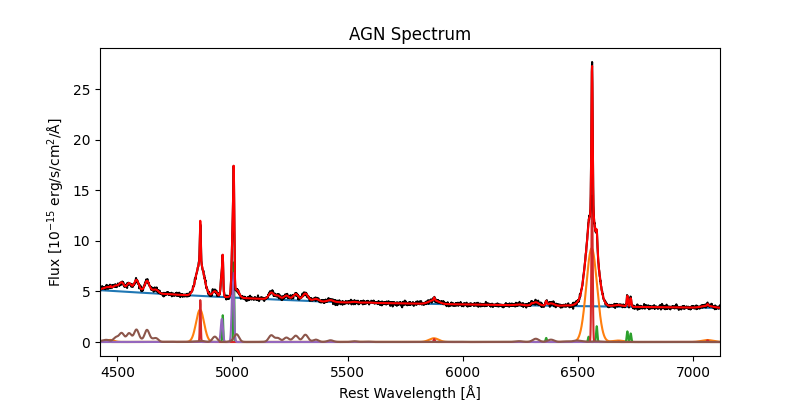

In [9]:
plt.figure(figsize=(8, 4))

comps = models.get_components(fitted_model, additive=True)
for name in comps.names:
    plt.plot(spec.wave, comps[name](spec.wave), label=name)

plt.plot(spec.wave, spec.flux, label='Data', color='black')
plt.plot(spec.wave, fitted_model(spec.wave), label='Model', color='red')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel('Flux [10$^{-15}$ erg/s/cm$^2$/Å]')

# plt.ylim(bottom=0.1)
# plt.yscale('log')

plt.title(spec.name)

plt.show()

In [10]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
oiii_out.flux

,value,std
[OIII]5007,104.052997,0.486764


In [11]:
# If the fitter uses covariance in the fitting process, by default we will add the .std attribute to the parameters of the model.
# In some cases you might want to estimate the uncertainties on the best-fit parameters using more robust methods, such as bootstrapping.
# We implement it in an easy way in prism, and it can be used with any of the available fitters.
# We perturb the data around their uncertainties, and we refit the model to each perturbed dataset.
# This will give us a distribution of best-fit parameters from which we can estimate the uncertainties.
# We supprt parallelized fitting! For simple models and small datasets, you can set nproc=1 to avoid the overhead of parallelization.
# For more complex models and larger datasets, you can increase nproc to speed up the process.

from prism.modeling.fitting.uncertainty import bootstrap, resample_attach

fitter = fitting.AstroTRF()

samples = bootstrap(model=fitted_model, 
                    fitter=fitter,
                    x=spec.wave, y=spec.flux, yerr=spec.err,
                    n_samples=200, seed=11,
                    nproc=4,
                    )

# Add the .lolim and .uplim attrubutes to the parameters of the fitted model.
# If nan it means the parameter is unconstrained. By default we guve 68% confidence intervals.
resample_attach(fitted_model, samples)

Fitting spectra:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Bootstrap complete: 200/200 successful


In [12]:
# Print the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'lolim') and param.lolim is not None:
        print(f"  {name:16s}: [{param.lolim:8.4f}, {param.uplim:8.4f}]")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     : [  3.9120,   3.9150]
  x_ref_0         : [5482.9375, 5487.2370]
  index1_0        : [ -1.2540,  -1.2490]
  index2_0        : [  0.6704,   0.6756]
  amp_hb4861_1    : [  3.1943,   3.1981]
  amp_ha6562_1    : [  9.2410,   9.2669]
  amp_hei4471_1   : [  0.1929,   0.2170]
  amp_heii4685_1  : [     nan,   0.0108]
  amp_hei5877_1   : [  0.3684,   0.3703]
  amp_hei6678_1   : [  0.1421,   0.1452]
  amp_hei7065_1   : [  0.1940,   0.1983]
  offset_1        : [-131.8529, -130.9329]
  fwhm_1          : [2501.5835, 2503.3468]
  redshift_1      :   0.0000
  amp_oiii5007_2  : [  7.8560,   8.0259]
  amp_nii6583_2   : [  1.5545,   1.6026]
  amp_oi6300_2    : [  0.0850,   0.1352]
  amp_oi6363_2    : [  0.3893,   0.4226]
  amp_sii6716_2   : [  1.0408,   1.0733]
  amp_sii6730_2   : [  0.8519,   0.8579]
  offset_2        : [-59.1735, -57.9468]
  fwhm_2          : [270.7053, 274.5410]
  redshift_2      :   0.0000
  amp_hb4861_3    : [  4.0496,   4.2633]
  amp_ha6562_3    : [ 14.3092,  14

In [13]:
# The user can also save the fitted model and its parameters to a file, and load them later for inspection or further analysis, without the need to re-run the fitting process from scratch.
from prism.modeling.io import load_params, load_model

outfile = "results/agnmodel.fits"
fitted_model.save(outfile, overwrite=True)

lp = load_params(outfile)
lm = load_model(outfile)
print("amp_hb:", lp["amp_hb4861_1"])
print("model class:", type(lm).__name__)

amp_hb: 3.1957341138636894
model class: CompoundModel
